In [2]:
import os
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

In [3]:
import numpy as np
from soil_diskin.utils import *
import scipy as sp
import matplotlib.pyplot as plt
from soil_diskin.compartmental_models import *
import pandas as pd
from soil_diskin.constants import *
from  scipy.io import loadmat
# autoreload modules
%load_ext autoreload
%autoreload 2

### Test for CLM4.5

In [4]:
os.getcwd()

'/Users/yinonmb/soil_diskin'

In [5]:
# load soil depth mat file 
fn = 'data/CLM5_global_simulation/soildepth.mat'
mat = loadmat(fn)
zisoi = mat['zisoi'].squeeze()
zsoi = mat['zsoi'].squeeze()
dz = mat['dz'].squeeze()
dz_node = mat['dz_node'].squeeze()

# load gridded nc file with the inputs, initial values, and the environmental variables
global_da = xr.open_dataset('data/CLM5_global_simulation/global_demo_in.nc')
global_da = global_da.rename({'LON':'x','LAT':'y'})
def fix_lon(ds):
    ds['x'] = xr.where(ds['x']>=180,ds['x']-360,ds['x'])
    return ds.sortby('x')

global_da = fix_lon(global_da)
global_da = global_da.rio.write_crs("EPSG:4326", inplace=True)

# define model parameters
CLM_params = xr.open_dataset('data/CLM5_global_simulation/clm5_params.c171117.nc')
taus = np.array([CLM_params['tau_cwd'],CLM_params['tau_l1'],CLM_params['tau_l2_l3'],CLM_params['tau_l2_l3'],CLM_params['tau_s1'],CLM_params['tau_s2'],CLM_params['tau_s3']]).squeeze()
Gamma_soil = 1e-4 
F_soil = 0

/var/folders/nd/g4twhtn15zx6m9lyffycx40c0000gp/T/ipykernel_51673/938159974.py:20: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  CLM_params = xr.open_dataset('data/CLM5_global_simulation/clm5_params.c171117.nc')


In [6]:
config = ConfigParams(decomp_depth_efolding=0.5, taus=taus, Gamma_soil=Gamma_soil, F_soil=F_soil,
                      zsoi=zsoi, zisoi=zisoi, dz=dz, dz_node=dz_node, nlevels=10, npools=7)
global_data = GlobalData(global_da)

site_data = pd.read_csv('results/all_sites_14C_turnover.csv')
row = site_data.iloc[0]
ldd = global_data.make_ldd(*row[['Latitude','Longitude']].values)
CLM_model = CLM5(config, ldd)
ldd_no_input = LocDependentData(w=ldd.w, t=ldd.t, o=ldd.o, n=ldd.n, sand=ldd.sand, I=xr.zeros_like(ldd.I), X0=ldd.X0)
CLM_model_no_input = CLM5(config, ldd_no_input)


In [10]:
M = CLM_model.A @ CLM_model.K_ts.mean(axis=0) - CLM_model.V
I_bar = np.asarray(CLM_model.I).mean(axis=0)
n = M.shape[0]

# Slowest mode of the system sets how long spin-up has to run.
real_eigs = np.linalg.eigvals(M).real
tau_slow = -1.0 / real_eigs[real_eigs < 0].max()

# Integrate the spin-up for this many multiples of the slowest e-folding
# time. 15 leaves a relative residual of about exp(-5) ~ 1e-2.
SPINUP_TAU_MULTIPLE = 5
spinup_time = tau_slow * SPINUP_TAU_MULTIPLE
spinup_time

/var/folders/nd/g4twhtn15zx6m9lyffycx40c0000gp/T/ipykernel_51673/2934186105.py:1: RuntimeWarning: divide by zero encountered in matmul
  M = CLM_model.A @ CLM_model.K_ts.mean(axis=0) - CLM_model.V
/var/folders/nd/g4twhtn15zx6m9lyffycx40c0000gp/T/ipykernel_51673/2934186105.py:1: RuntimeWarning: overflow encountered in matmul
  M = CLM_model.A @ CLM_model.K_ts.mean(axis=0) - CLM_model.V
/var/folders/nd/g4twhtn15zx6m9lyffycx40c0000gp/T/ipykernel_51673/2934186105.py:1: RuntimeWarning: invalid value encountered in matmul
  M = CLM_model.A @ CLM_model.K_ts.mean(axis=0) - CLM_model.V


np.float64(130352.3885636481)

In [11]:
# run a simulation with the full model for a long time to reach steady state, then run the model with no input to see how the system decays
ts_long = np.logspace(-1, np.log10(spinup_time), 1000)  # time in years
labeled_long = solve_ivp(CLM_model._dX, (0, spinup_time), np.zeros(70), t_eval=ts_long, method='LSODA')
unlabeled_long = solve_ivp(CLM_model_no_input._dX, (0, spinup_time), labeled_long.y[:,-50:].mean(axis=1), t_eval=ts_long, method='LSODA')

totC_long = unlabeled_long.y.sum(axis=0) + labeled_long.y.sum(axis=0)
age_CDF_long = labeled_long.y.sum(axis=0) / totC_long

# save the results to a csv file
labeled_pools_long = pd.DataFrame(labeled_long.y, columns=ts_long)
unlabeled_pools_long = pd.DataFrame(unlabeled_long.y, columns=ts_long)
labeled_pools_long.to_csv('results/experimental/clm45_normal_run_steady_state.csv')
unlabeled_pools_long.to_csv('results/experimental/clm45_normal_run_steady_state_unlabeled.csv')
totC_long = unlabeled_long.y.sum(axis=0) + labeled_long.y.sum(axis=0)
age_CDF_long = labeled_long.y.sum(axis=0) / totC_long

/Users/yinonmb/soil_diskin/soil_diskin/compartmental_models.py:420: RuntimeWarning: divide by zero encountered in matmul
  dX = I_t + self._ops[t_ind] @ X
/Users/yinonmb/soil_diskin/soil_diskin/compartmental_models.py:420: RuntimeWarning: overflow encountered in matmul
  dX = I_t + self._ops[t_ind] @ X
/Users/yinonmb/soil_diskin/soil_diskin/compartmental_models.py:420: RuntimeWarning: invalid value encountered in matmul
  dX = I_t + self._ops[t_ind] @ X


In [12]:
# read the results of the long run and of the steady state profiles from the csv files

labeled_pools_long = pd.read_csv('results/experimental/clm45_normal_run_steady_state.csv', index_col=0)
unlabeled_pools_long = pd.read_csv('results/experimental/clm45_normal_run_steady_state_unlabeled.csv', index_col=0)
totC_long = unlabeled_pools_long.sum(axis=0) + labeled_pools_long.sum(axis=0)
age_CDF_long = labeled_pools_long.sum(axis=0) / totC_long
xss = pd.read_csv('results/experimental/clm45_sasu_steady_state_profiles.csv', index_col=[0,1])


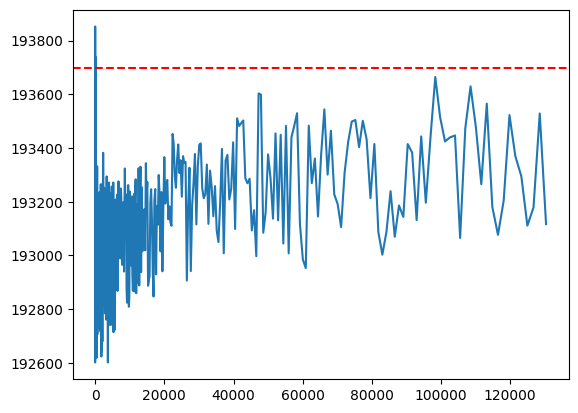

In [13]:
plt.plot(ts_long, totC_long)
plt.axhline(y=xss.sum(axis=1).iloc[0], color='r', linestyle='--', label='Steady-state total C')

In [14]:
# calculate the analytical approximation of the age distribution using the mean input and the mean transition matrix
M = CLM_model.A @ CLM_model.K_ts.mean(axis=0) - CLM_model.V
I_bar = np.asarray(CLM_model.I).mean(axis=0)
analytical_aproximation = calc_age_dist_cdf(M, I_bar, ts_long)

/var/folders/nd/g4twhtn15zx6m9lyffycx40c0000gp/T/ipykernel_51673/335272575.py:2: RuntimeWarning: divide by zero encountered in matmul
  M = CLM_model.A @ CLM_model.K_ts.mean(axis=0) - CLM_model.V
/var/folders/nd/g4twhtn15zx6m9lyffycx40c0000gp/T/ipykernel_51673/335272575.py:2: RuntimeWarning: overflow encountered in matmul
  M = CLM_model.A @ CLM_model.K_ts.mean(axis=0) - CLM_model.V
/var/folders/nd/g4twhtn15zx6m9lyffycx40c0000gp/T/ipykernel_51673/335272575.py:2: RuntimeWarning: invalid value encountered in matmul
  M = CLM_model.A @ CLM_model.K_ts.mean(axis=0) - CLM_model.V
/Users/yinonmb/soil_diskin/soil_diskin/age_dist_utils.py:37: RuntimeWarning: divide by zero encountered in matmul
  elem_shape = np.shape(np.asarray(z) @ np.eye(A.shape[0]) @ np.asarray(v))
/Users/yinonmb/soil_diskin/soil_diskin/age_dist_utils.py:37: RuntimeWarning: overflow encountered in matmul
  elem_shape = np.shape(np.asarray(z) @ np.eye(A.shape[0]) @ np.asarray(v))
/Users/yinonmb/soil_diskin/soil_diskin/age_di

(0.0, 1.0)

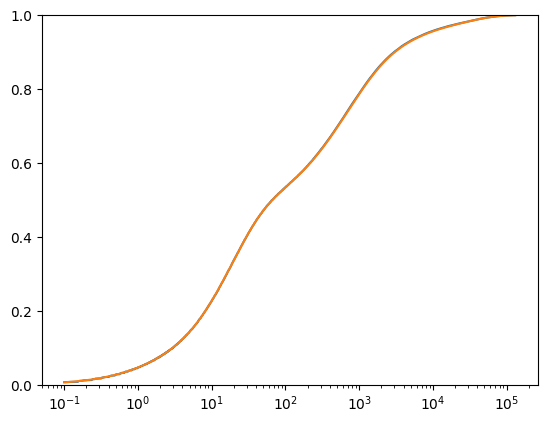

In [15]:
plt.semilogx(ts_long, age_CDF_long)
plt.semilogx(ts_long, analytical_aproximation)
plt.ylim(0, 1)